# Project 4 — NLP & Sentiment Analysis

**DecodeLabs Data Science Internship — Project 4**

### Project Continuation
Projects 1–3 analyzed the e-commerce business from structured data: transaction performance, fraud patterns, and customer purchasing behavior. This project extends that analysis into **unstructured customer feedback** by studying product reviews and sentiment.

The review dataset is a separate public dataset. It is **not merged with the previous e-commerce dataset**, because there is no verified shared customer/review identifier. This avoids creating an artificial relationship between unrelated records.

### Objective
Build an NLP (Natural Language Processing) pipeline that:
1. Loads a labeled product-review dataset.
2. Preprocesses review text using tokenization, stop-word removal, and lemmatization.
3. Converts text into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency).
4. Trains a sentiment classifier using Naive Bayes.
5. Evaluates the classifier.
6. Predicts the sentiment of new reviews.

**Sentiment classes:** Positive / Negative


## 1. Install and Import Dependencies

We use:
- `kagglehub` to load the Kaggle dataset.
- `pandas` for data handling.
- `NLTK` for tokenization, stop-word removal, and lemmatization.
- `scikit-learn` for TF-IDF, train/test splitting, Naive Bayes, and evaluation.


In [1]:
# Install dependencies
!pip install -q "kagglehub[pandas-datasets]" nltk scikit-learn seaborn matplotlib

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Review Dataset

For Project 4 we use the selected labeled Amazon review dataset:

`walimuhammadahmad/amazone-reviews`

This dataset provides the unstructured text needed for the NLP stage of the internship. It is intentionally kept separate from the transaction dataset used in Projects 1–3 because no verified shared record key was established.


## 2. Download / Load the Dataset

This cell uses the dataset source you selected:

`walimuhammadahmad/amazone-reviews`

We first inspect the files available in the Kaggle dataset because the exact CSV filename is not specified in the provided loading code.


In [3]:
# Find the latest downloaded dataset files
dataset_path = kagglehub.dataset_download("walimuhammadahmad/amazone-reviews")
print("Dataset downloaded to:", dataset_path)

from pathlib import Path

files = list(Path(dataset_path).rglob("*"))
data_files = [f for f in files if f.is_file()]

print("\nFiles found:")
for f in data_files:
    print(f)

100%|██████████| 68.5M/68.5M [00:00<00:00, 76.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/walimuhammadahmad/amazone-reviews/versions/2

Files found:
/root/.cache/kagglehub/datasets/walimuhammadahmad/amazone-reviews/versions/2/amazon_reviews.csv


In [4]:
# Try to load the dataset through KaggleHub's Pandas adapter.
# If the dataset contains more than one file, select the CSV filename printed above.

csv_files = [f for f in data_files if f.suffix.lower() == ".csv"]

if not csv_files:
    raise FileNotFoundError("No CSV file was found in the downloaded dataset.")

print("CSV files found:")
for i, f in enumerate(csv_files):
    print(i, "->", f.name)

# Select the first CSV by default.
# If the printed list shows another file is the actual review dataset,
# change CSV_INDEX below.
CSV_INDEX = 0
selected_file = csv_files[CSV_INDEX].name
print("\nSelected file:", selected_file)

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "walimuhammadahmad/amazone-reviews",
    selected_file
)

print("\nFirst 5 records:")
display(df.head())

CSV files found:
0 -> amazon_reviews.csv

Selected file: amazon_reviews.csv


/tmp/ipykernel_1304/2288017598.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'amazone-reviews' dataset.

First 5 records:


,Review,Label
0,Great CD: My lovely Pat has one of the GREAT v...,1
1,One of the best game music soundtracks - for a...,1
2,Batteries died within a year ...: I bought thi...,0
3,"works fine, but Maha Energy is better: Check o...",1
4,Great for the non-audiophile: Reviewed quite a...,1


## 3. Understand the Dataset

Before preprocessing, inspect:
- number of rows and columns,
- column names,
- missing values,
- data types,
- sentiment distribution.

**Important:** We do not assume the exact column names until we inspect the downloaded dataset.


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (400000, 2)

Columns:
['Review', 'Label']

Data types:


,0
Review,object
Label,int64



First 5 rows:


,Review,Label
0,Great CD: My lovely Pat has one of the GREAT v...,1
1,One of the best game music soundtracks - for a...,1
2,Batteries died within a year ...: I bought thi...,0
3,"works fine, but Maha Energy is better: Check o...",1
4,Great for the non-audiophile: Reviewed quite a...,1


In [6]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,0
Review,0
Label,0



Duplicate rows: 0


## 4. Identify the Review and Sentiment Columns

The model needs:
- one column containing the review text,
- one column containing the sentiment label.

The following helper tries common column names. If the dataset uses different names, the code will show the available columns so they can be selected manually.


In [7]:
def find_column(columns, candidates):
    normalized = {str(c).strip().lower(): c for c in columns}
    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]
    return None

TEXT_CANDIDATES = [
    "review", "reviews", "text", "review_text", "comment", "content"
]

LABEL_CANDIDATES = [
    "label", "sentiment", "sentiment_label", "class", "target"
]

TEXT_COLUMN = find_column(df.columns, TEXT_CANDIDATES)
LABEL_COLUMN = find_column(df.columns, LABEL_CANDIDATES)

print("Detected text column:", TEXT_COLUMN)
print("Detected label column:", LABEL_COLUMN)

if TEXT_COLUMN is None or LABEL_COLUMN is None:
    print("\nAvailable columns:")
    print(df.columns.tolist())
    raise ValueError(
        "Could not automatically identify the review and sentiment columns. "
        "Set TEXT_COLUMN and LABEL_COLUMN manually using the column names above."
    )

Detected text column: Review
Detected label column: Label


In [8]:
# Keep only the two columns needed for this project
data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ["review", "sentiment"]

# Remove missing values
data = data.dropna(subset=["review", "sentiment"])

# Remove exact duplicate review/label pairs
data = data.drop_duplicates()

# --- ADD YOUR SAMPLING LINE HERE ---
sample_size = min(20000, len(data))
data = data.sample(sample_size, random_state=42).reset_index(drop=True)

print("Reviews used:", len(data))
print("Shape after basic cleaning:", data.shape)
display(data.head())

Reviews used: 20000
Shape after basic cleaning: (20000, 2)


,review,sentiment
0,This is a great book: I must preface this by s...,1
1,"Huge Disappointment.: As a big time, long term...",0
2,Wayne is tight but cant hang with Turk.: This ...,1
3,Excellent: I read this book when I was in elem...,1
4,Not about Anusara: Although this book is toute...,0


In [9]:
print("Unique sentiment labels:")
print(data["sentiment"].value_counts())

print("\nUnique label values:")
print(data["sentiment"].unique())

Unique sentiment labels:
sentiment
1    10034
0     9966
Name: count, dtype: int64

Unique label values:
[1 0]


## 5. Convert Labels to Positive / Negative

Project 4 requires binary sentiment classification.

If the dataset already contains `positive` and `negative`, we keep them.

If it uses numeric labels such as `0` and `1`, we inspect their meaning before mapping them. The mapping below is designed for the selected Amazon dataset's expected binary-label format.

If your dataset output shows different labels, update the mapping after inspecting the values above.


In [10]:
# Normalize text labels first
data["sentiment"] = data["sentiment"].astype(str).str.strip().str.lower()

print("Labels after normalization:")
print(data["sentiment"].value_counts())

Labels after normalization:
sentiment
1    10034
0     9966
Name: count, dtype: int64


In [11]:
# Handle common binary-label formats.
# If the dataset already contains positive/negative, this keeps them unchanged.

label_values = set(data["sentiment"].unique())

if label_values <= {"positive", "negative"}:
    pass
elif label_values <= {"0", "1"}:
    data["sentiment"] = data["sentiment"].map({
        "0": "negative",
        "1": "positive"
    })
else:
    raise ValueError(
        f"Unexpected sentiment labels: {sorted(label_values)}. "
        "Inspect the labels and create the correct mapping before continuing."
    )

print("Final sentiment distribution:")
display(data["sentiment"].value_counts())

Final sentiment distribution:


,count
sentiment,
positive,10034
negative,9966


## Project Context

The first three projects established an e-commerce analytics foundation using structured transaction data. In this project, we add a different type of business signal: **customer language**.

Because the selected review dataset does not contain a verified key shared with the earlier e-commerce dataset, we analyze it as a separate customer-feedback dataset rather than fabricating a merge.


## 6. Download NLTK Resources

These resources support:
- tokenization,
- English stop-word removal,
- lemmatization.


In [12]:
# --- UPDATE NLTK DOWNLOADS ---
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")  # Added for POS tagging
try:
    nltk.download("averaged_perceptron_tagger_eng")  # required name on newer NLTK versions
except Exception:
    pass
nltk.download("omw-1.4")

# --- UPDATE STOP WORDS (Keep Negations) ---
default_stopwords = set(stopwords.words("english"))
negations = {
    "no", "not", "nor", "neither", "never", "none", "cannot",
    "couldn't", "didn't", "doesn't", "hadn't", "hasn't", "haven't",
    "isn't", "mightn't", "mustn't", "needn't", "shan't", "shouldn't",
    "wasn't", "weren't", "won't", "wouldn't"
}
stop_words = default_stopwords - negations

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 7. Text Pre-processing

The required preprocessing pipeline is:

**Raw review → lowercase → remove unnecessary characters → tokenization → stop-word removal → lemmatization**

Example:

`"I absolutely loved this product!"`

becomes a cleaner sequence of meaningful words before TF-IDF.


In [13]:
lemmatizer = WordNetLemmatizer()

# --- POS TAG HELPER ---
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# --- PREPROCESSING FUNCTION ---
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)

    # Filter with custom stop words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]

    # POS-guided lemmatization
    pos_tags = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]

    return " ".join(tokens)

data["cleaned_review"] = data["review"].apply(preprocess_text)

display(data[["review", "cleaned_review", "sentiment"]].head(10))

,review,cleaned_review,sentiment
0,This is a great book: I must preface this by s...,great book must preface say not religious love...,positive
1,"Huge Disappointment.: As a big time, long term...",huge disappointment big time long term trevani...,negative
2,Wayne is tight but cant hang with Turk.: This ...,wayne tight cant hang turk album hot want howe...,positive
3,Excellent: I read this book when I was in elem...,excellent read book elementary school probably...,positive
4,Not about Anusara: Although this book is toute...,not anusara although book tout several anusara...,negative
5,Worst DVD Ever purchased: This was the very wo...,bad dvd ever purchase bad dvd ever purchase te...,negative
6,"Not the strongest fan, but gets the job done.:...",not strong fan get job do sure upgrade spend n...,positive
7,Bottom of the casebook barrel: At the beginnin...,bottom casebook barrel begin first year law sc...,negative
8,"Hilarious!: This movie is very sweet, I love i...",hilarious movie sweet love funny omigod favori...,positive
9,"The swinging, sadly, occurs only in the title....",swing sadly occur title sad say jason sidemen ...,negative


In [14]:
# Check for reviews that became empty after preprocessing
empty_reviews = (data["cleaned_review"].str.strip() == "").sum()

print("Empty cleaned reviews:", empty_reviews)

if empty_reviews > 0:
    data = data[data["cleaned_review"].str.strip() != ""]

print("Dataset after preprocessing:", data.shape)

Empty cleaned reviews: 0
Dataset after preprocessing: (20000, 3)


## 8. Explore the Cleaned Dataset

Check how many positive and negative examples are available.


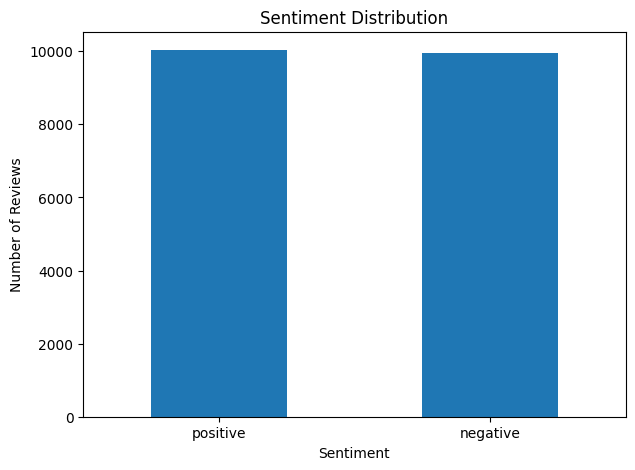

In [15]:
plt.figure(figsize=(7, 5))
data["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## 9. Train / Test Split

We separate the data before fitting the TF-IDF vectorizer.

- **80%** → training data
- **20%** → testing data

Stratification keeps the positive/negative class proportions approximately consistent.


In [16]:
X_text = data["cleaned_review"]
y = data["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train_text))
print("Testing reviews:", len(X_test_text))

Training reviews: 16000
Testing reviews: 4000


## 10. TF-IDF Vectorization

TF-IDF converts the preprocessed text into numerical feature vectors.

The vectorizer is **fit only on the training text** to avoid leaking information from the test set.


In [17]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Training TF-IDF shape: (16000, 10000)
Testing TF-IDF shape: (4000, 10000)
Vocabulary size: 10000


## 11. Train the Naive Bayes Classifier

Project 4 allows either **Naive Bayes or SVM**.

Here we use **Multinomial Naive Bayes**, a common choice for text classification with TF-IDF features.


In [18]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## 12. Predict Test Reviews


In [19]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred
})

display(results.head(20))

,actual,predicted
0,positive,positive
1,negative,negative
2,positive,positive
3,negative,negative
4,negative,negative
5,positive,positive
6,negative,positive
7,negative,negative
8,negative,positive
9,positive,positive


## 13. Evaluate the Model

We report:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8595
Accuracy: 85.95%

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      1993
    positive       0.86      0.87      0.86      2007

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000



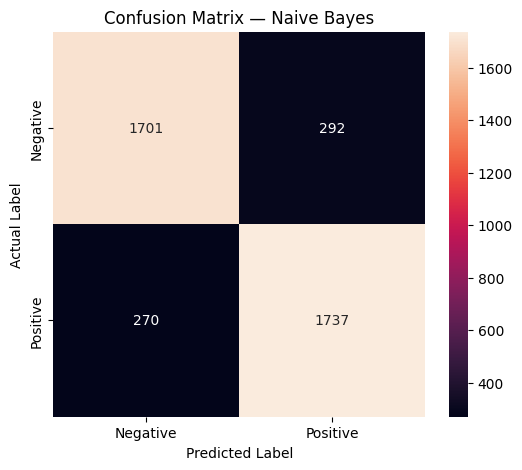

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "positive"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix — Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 14. Test the Model With New Reviews

This demonstrates the project's required final step: using the trained NLP pipeline to classify unseen product-review text as Positive or Negative.

**Important:** new text must go through the same preprocessing and the already-fitted TF-IDF vectorizer.


In [22]:
new_reviews = [
    "I absolutely love this product. The quality is amazing!",
    "This was a terrible purchase. The product broke very quickly.",
    "The item works perfectly and I am very happy with it.",
    "Very disappointing quality and definitely not worth the money."
]

cleaned_new_reviews = [preprocess_text(review) for review in new_reviews]
new_vectors = vectorizer.transform(cleaned_new_reviews)
new_predictions = model.predict(new_vectors)

for review, prediction in zip(new_reviews, new_predictions):
    print(f"Review: {review}")
    print(f"Predicted sentiment: {prediction.upper()}")
    print("-" * 80)

Review: I absolutely love this product. The quality is amazing!
Predicted sentiment: POSITIVE
--------------------------------------------------------------------------------
Review: This was a terrible purchase. The product broke very quickly.
Predicted sentiment: NEGATIVE
--------------------------------------------------------------------------------
Review: The item works perfectly and I am very happy with it.
Predicted sentiment: POSITIVE
--------------------------------------------------------------------------------
Review: Very disappointing quality and definitely not worth the money.
Predicted sentiment: NEGATIVE
--------------------------------------------------------------------------------


## 15. Optional: Predict a User-Entered Review


In [23]:
try:
    user_review = input("Enter a review: ")
except EOFError:
    user_review = ""
    print("No interactive input available — skipping this optional step.")

if user_review.strip():
    cleaned = preprocess_text(user_review)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    print("\nPredicted sentiment:", prediction.upper())


Enter a review: the product seems very good outside while tricky inside

Predicted sentiment: NEGATIVE


## 16. Save the Processed Dataset

Saving the cleaned dataset makes the preprocessing result reproducible and gives us an artifact for the project folder.


In [24]:
output_file = "project4_cleaned_reviews.csv"
data.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: project4_cleaned_reviews.csv


# Conclusion

This project extends the earlier DecodeLabs e-commerce analysis from structured customer and transaction data into unstructured customer feedback.

### Completed requirements

- [x] Loaded a labeled product-review dataset
- [x] Cleaned the text
- [x] Tokenized reviews
- [x] Removed stop words
- [x] Lemmatized words
- [x] Converted text into numerical features using TF-IDF
- [x] Trained a Naive Bayes classifier
- [x] Predicted Positive / Negative sentiment
- [x] Evaluated the model using accuracy and a classification report
- [x] Visualized the confusion matrix
- [x] Tested the model on new reviews

### Connection to Projects 1–3

Projects 1–3 focused on **what happens in the e-commerce business**: transactions, potentially fraudulent behavior, and customer purchasing patterns. Project 4 focuses on **what customers say about products** through review sentiment.

The datasets are kept separate rather than being artificially joined. Therefore, this notebook does not claim that the Amazon reviewers are the same customers identified in Project 3.

### Final workflow

**Product Review → Preprocessing → TF-IDF → Naive Bayes → Sentiment Prediction**
